# Basic tutorial

Welcome to the basic tutorial of the *particles_cdssm* package - this package uses a similar user interface to the *particles* package.
The main difference is the class of model of interest: the *particles* package implements 
Sequential Monte Carlo methods for inference on state-space models, whereas this package conducts inference on the class of continuous-discrete 
state space models.

## First steps: defining a continuous-discrete state space model

We start by importing some standard libraries, plus some modules from the *particles* package. We will recall how to build a state space model from the *particles* package, then show how to build a continuous-discrete state space model with the *particles_cdssm* package:

In [1]:
%matplotlib inline
import warnings; warnings.simplefilter('ignore')  # hide warnings 

# standard libraries
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb

# modules from particles
import particles  # core module
from particles import distributions as dists  # where probability distributions are defined
from particles import state_space_models as ssm  # where state-space models are defined
from particles.collectors import Moments

A simple example of a state-space model is given by the basic stochastic volatility model: 
\begin{align*}
X_0 & \sim N\left(\mu, \frac{\sigma^2}{1-\rho^2}\right), &\\
X_t|X_{t-1}=x_{t-1} & \sim N\left( \mu + \rho (x_{t-1}-\mu), \sigma^2\right), &\quad t\geq 1, \\
Y_t|X_t=x_t & \sim N\left(0, e^{x_t}\right),& \quad t\geq 0.
\end{align*}
 
Note that this model depends on fixed parameter $\theta=(\mu, \rho, \sigma)$. 

In case you are not familiar with the notations above: a state-space model is a model for a joint process $(X_t, Y_t)$, where $(X_t)$ is an unobserved Markov process (the *state* of the system), and $Y_t$ is some noisy measurement of $X_t$ (hence it is observed). For instance, in stochastic volatility, $Y_t$ is typically the log-return of some asset, and $X_t$ its (unobserved) log-volatility.

Using the *particles* package, one can define a stochastic volatility model as follows: 

In [2]:
class StochVol(ssm.StateSpaceModel):
    def PX0(self):  # Distribution of X_0
        return dists.Normal(loc=self.mu, scale=self.sigma / np.sqrt(1. - self.rho**2))
    def PX(self, t, xp):  # Distribution of X_t given X_{t-1}=xp (p=past)
        return dists.Normal(loc=self.mu + self.rho * (xp - self.mu), scale=self.sigma)
    def PY(self, t, xp, x):  # Distribution of Y_t given X_t=x (and possibly X_{t-1}=xp)
        return dists.Normal(loc=0., scale=np.exp(0.5 * x))
   
my_model = StochVol(mu=-1., rho=.95, sigma=.1)  # actual model

Recall: Methods `PX0`, `PX` and `PY` return objects that represent probability distributions (defined in module `particles.distributions`. Parameters $\mu$, $\rho$ and $\sigma$ are defined as **attributes** of a class instance: i.e. `self.mu` and so on. (`self` is the generic name for an instance of a class in Python.)

If your are not very familiar with OOP (object oriented programming) and related concepts (classes, instances, etc.), here is a simple way to understand them in our context: 

* The **class** `StochVol` represents the parametric class of stochastic volatility models.

* The object `my_model` (a **class instance** of `StochVol`) defines a particular model, where parameters $\mu$, $\rho$ and $\sigma$ are fixed to certain values. 

In particular, we can inspect the attributes of `my_model` that store the parameter values. 

In [3]:
my_model.mu, my_model.rho, my_model.sigma

(-1.0, 0.95, 0.1)

Having constructed the state space model, defined as `my_model`, we may simulate from the model as follows: 

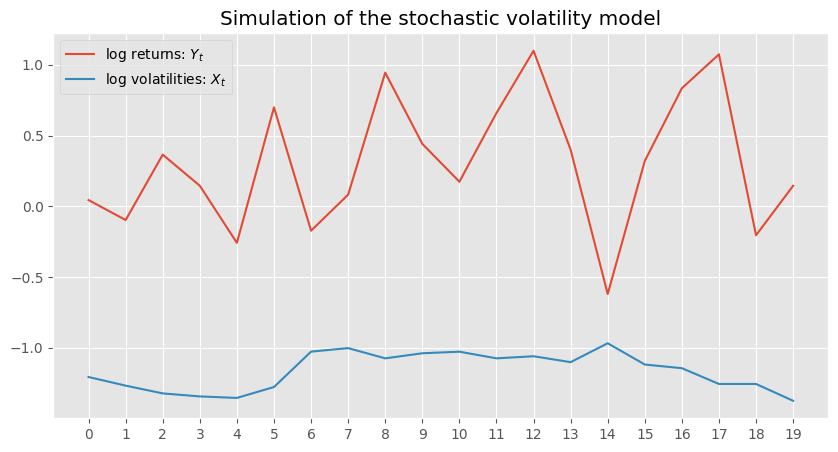

In [4]:
true_states, data = my_model.simulate(20)  # we simulate from the model 100 data points

plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(data, label=r'log returns: $Y_t$')
plt.plot(true_states, label=r'log volatilities: $X_t$')
plt.xticks(np.arange(0, 20, 1))
plt.title('Simulation of the stochastic volatility model')
plt.legend()
plt.show()

Class `StochVol` is a sub-class of ``StateSpaceModel``. (You can see that from the first line of its definition.) For instance, it inherits a method called `simulate` that generates states and datapoints from the considered model.  

Now, we consider an alternative approach to model log-volatility: via a continuous-discrete state space model - we import some modules from the package: 

In [5]:
import particles_cdssm as pcdssm
from particles_cdssm import continuous_discrete_ssms as cdssms
from particles_cdssm import sdes
from particles_cdssm import feynman_kac as cdfk
from particles_cdssm import tools

A alternative **continuous-discrete** state space model for stochastic volatility could be defined as follows:

\begin{align*}
\textrm{Initial Distribution:} \quad X(0) &\sim \mathcal{N}(\mu, \frac{\phi^2}{2\rho}) \\
\textrm{Continuous Latent State process}: \quad dX(s) &= \rho(\mu - X(s))ds + \phi dB(s) ,& \quad s \in [0, S].\\
\textrm{Observation Density: } \quad Y_t | X(t) &= x(t) \sim \mathcal{N}(0, e^{x(t)}) ,& \quad t\in \{0, 1, 2, \dots, T-1\}.
\end{align*}

The key difference between a state-space model and a continuous-discrete state-space model, is that the latent state is defined as a continuous time process: a stochastic differential equation (SDE). 

Put another way, in a (standard) state space model, for each observation ($Y_t$) we have a corresponding latent state ($X_t$). For the continuous-discrete state space model, the latent state evolves as a continuous-time stochastic process $X(s)$ in continuous time $s \in [0, S]$, and this stochastic process is observed at discrete points in time $t \in \{0, 1, 2, \dots, T-1\}$, with noise through an observation density. 

In [6]:
rho=1.0; mu=-1.0; phi=0.2  # parameters of the Ornstein-Uhlenbeck process

# Initial distribution
initial_dist = dists.Normal(loc=mu, scale=phi/np.sqrt(2*rho))  # Initial distribution of the latent state

# Define the Ornstein Uhlenbeck SDE
class OrnsteinUhlenbeck(sdes.SDE):
    
    default_params = {'rho': 1.0, 'mu': -1.0, 'phi': 0.1} 
    
    def b(self, t, x):  # Drift function
        return self.rho * (self.mu - x)
    
    def sigma(self, t, x):  # Diffusion function
        return self.phi

ou_sde = OrnsteinUhlenbeck(rho=rho, mu=mu, phi=phi)  # Ornstein-Uhlenbeck SDE    

# Define the observation density as a method of a subclass of the CDSSM class: 

class StochVolCDSSM(cdssms.CDSSM):
    
    def PY(self, t, xp, x):
        return dists.Normal(loc=0., scale=np.exp(0.5 * x))

sv_cdssm = StochVolCDSSM(ou_sde, x0=initial_dist) # Stochastic volatility continuous-discrete state-space model

This is how we interpret what is going on in this case:

* The **class** `OrnsteinUhlenbeck` represents the parametric class of Ornstein Uhlenbeck SDEs.
* The object `ou_sde` (a **class instance** of `OrnsteinUhlenbeck`) represents the particular SDE, where $\rho$, $\mu$ and $\phi$ are set to certain values.
* The **class** `StochVolCDSSM` defines a generic CDSSM, for which when an instance of it is created by giving it as input an SDE and a initial distribution, will define a CD-SSM with the given observation density.
* the object `sv_cdssm` represents the cdssm given above, where $\rho$, $\mu$ and $\phi$ are set to certain values.


For the sde that we have defined, its parameters can be accessed as attritbutes of the CD-SSM:

In [7]:
sv_cdssm.rho, sv_cdssm.mu, sv_cdssm.phi

(1.0, -1.0, 0.2)

The object that defines the sde and the object defining the initial distribution are also accessible as attributes:

In [8]:
sv_cdssm.model_sde, sv_cdssm.x0 # (the SDE, the initial distribution)

(<__main__.OrnsteinUhlenbeck at 0x157423590>,
 <particles.distributions.Normal at 0x1574158d0>)

We can generate a simulation from the continuous-discrete state-space model, in a similar way to how we did it for the standard state-space model, with the `simulate` method:

Note the extra parameter `num`: in practice, the latent continuous-time process must be simulated on a discrete grid: this parameter defines the number of points on the grid between the observation times to use in the simulation. You can adjust this parameter and see what practical effect it has on the simulated path:

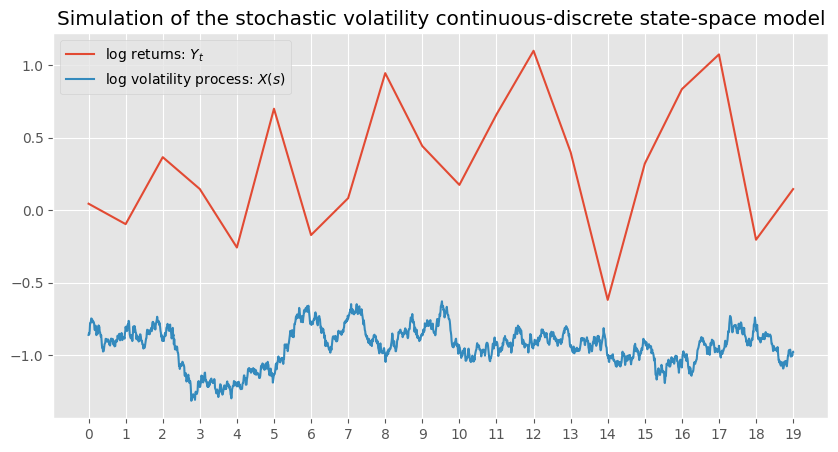

In [9]:
T = 20
true_path, cdssm_data = sv_cdssm.simulate(T, num=100)

path_arr = sum([[path[name][0] for name in path.dtype.names] for path in true_path], [])
times = np.linspace(0., T-1, len(path_arr))
obs_times = np.arange(0, T)

plt.figure(figsize=(10, 5))

plt.plot(obs_times, data, label=r'log returns: $Y_t$')
plt.plot(times, path_arr, label=r'log volatility process: $X(s)$')
plt.xticks(obs_times)
plt.legend()
plt.title('Simulation of the stochastic volatility continuous-discrete state-space model')
plt.show()

Comparing this plot of the continuous-discrete formulation of the stochastic volatility model to the (standard) state space model should help illustrate the key difference between a CD-SSM and a SSM. In a the finance context, the continuous-discrete modelling would be useful if the returns were observed daily, and we wanted to have an understanding not only an idea of the volatility for the full the trading day, but of how volatility evolves during the trading day.

## Particle filtering

Recall from the particles package that having defined a state space model, one can implement a *bootstrap* particle filter as follows: 

Below, we run a bootstrap particle filter using `N=100` particles and stratified resampling: 

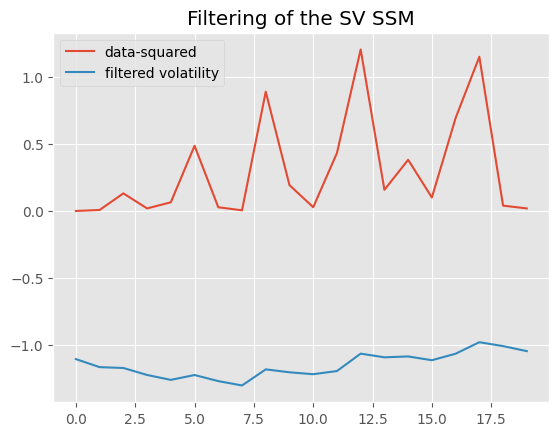

In [10]:
fk_model = ssm.Bootstrap(ssm=my_model, data=data)  # we use the Bootstrap filter
pf = particles.SMC(fk=fk_model, N=100, resampling='stratified', 
                   collect=[Moments()], store_history=True)  # the algorithm
pf.run()  # actual computation

# plot
plt.figure()
plt.plot([yt**2 for yt in data], label='data-squared')
plt.plot([m['mean'] for m in pf.summaries.moments], label='filtered volatility')
plt.title('Filtering of the SV SSM')
plt.legend()
plt.show()

Using almost identical syntax, we can run particle filters for cdssms with this package: we import the required modules:

In [11]:
cd_fk_model = cdfk.BootstrapDA(cdssm=sv_cdssm, data=cdssm_data)  # we use the Bootstrap filter
cd_pf = pcdssm.CDSSM_SMC(fk=cd_fk_model, N=100, resampling='stratified', 
                   collect=[Moments()], store_history=True, num=100)

cd_pf.run()

In this case, we define the Bootstrap `fk_model` using the `BootstrapDA` class. The DA in the name stands for 'data augmententation'. This is named as such because in the particle filter, we `augment' the data to a full continuous-time path between the observation times. 

We also have the extra parameter `num`: this defines the number of imputed points are used to simulate the paths in the particle filter between the observations times: 

We plot the results below:

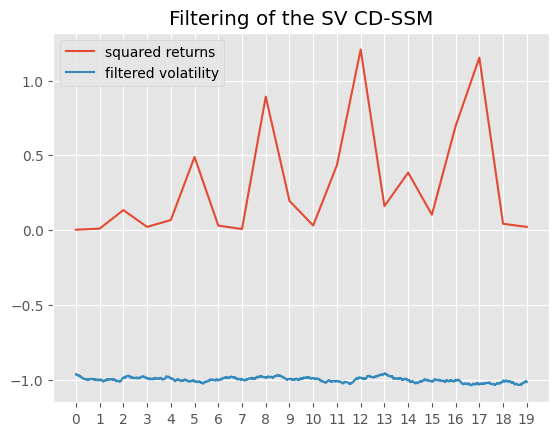

In [12]:
Xs, wgts = cd_pf.hist.X, cd_pf.hist.wgts
est_path_arr = sum([[np.average(X[name], weights=wgt.W) for name in X.dtype.names] for X, wgt in zip(Xs, wgts)], [])

plt.figure()

plt.plot(obs_times, [y_t ** 2 for y_t in data], label='squared returns')
plt.plot(times, est_path_arr, label='filtered volatility')
plt.xticks(obs_times)
plt.legend()
plt.title('Filtering of the SV CD-SSM')
plt.show()

The `particles` package also has a function to run multiple particle filters through a single command, through the `multiSMC` function. Since particle filters are Monte Carlo methods and their output is stochastic, this can be a helpful way of evaluating their performance:

For example, below we run the particle filter 30 times using 2 algorithms: one with $N=100$ and one with $N=1000$ particles:

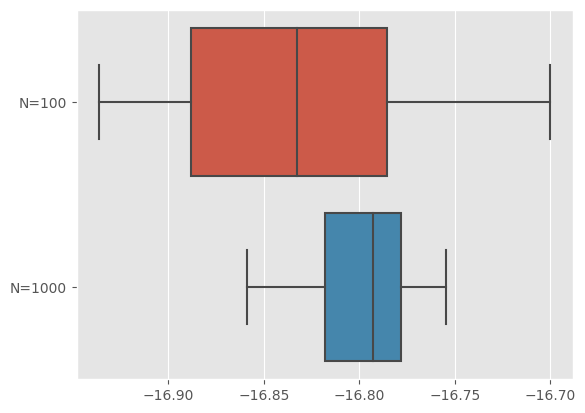

In [13]:
results = particles.multiSMC(fk=fk_model, N={'N=100': 100, 'N=1000': 1000}, nruns=30)
plt.figure()
sb.boxplot(x=[r['output'].logLt for r in results], y=[r['N'] for r in results])
plt.show()

As expected, using a larger number of particles reduces the variance of the output.

The `multiCDSSM_SMC` function allows one to do the same for particle filters for CD-SSMs:

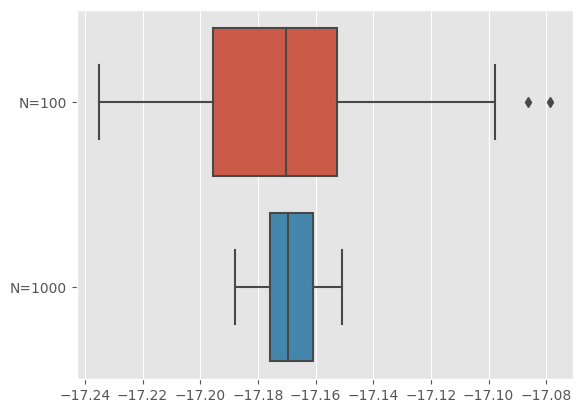

In [14]:
results = pcdssm.multiCDSSM_SMC(fk=cd_fk_model, N={'N=100': 100, 'N=1000': 1000}, nruns=30, num=100)
plt.figure()
sb.boxplot(x=[r['output'].logLt for r in results], y=[r['N'] for r in results])
plt.show()

The `multiCDSSM_SMC` function of this package enables one to do the same when working with cdssms: 

## Smoothing

Now let's consider particle algorithms for smoothing: here, in the standard state space model context, the goal is to come up with an estimate of $X_{0:T-1}$ given all the data $Y_{0:T-1}$:

Smoothing algorithms are also implemented in the particles package: given the full particle history, one can implement the standard version of the forward filtering, backward sampling algorithm as follows: 

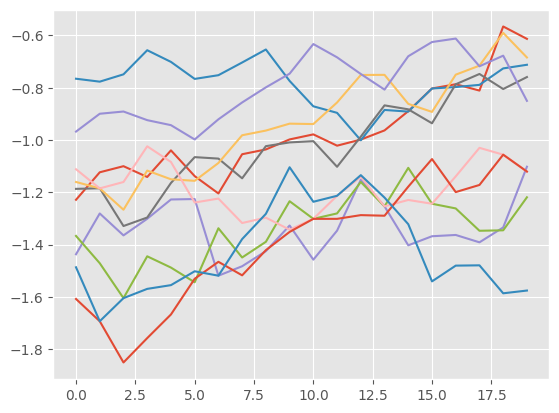

In [15]:
smooth_trajectories = pf.hist.backward_sampling_ON2(10) 
plt.figure()
plt.plot(smooth_trajectories);

In the case of cdssms, the smoothing problem is to infer the full path $X([0, T-1])$ given the observations $Y_{0:T-1}$ - this includes in between the observation times. Let's try to run a smoothing algorithm using a cdssm:

In [16]:
try:
    cd_pf.hist.backward_sampling_ON2(10)  # this won't work - if you run by it self an exception will be raised with the message printed below:
except NotImplementedError:
    print("To do smoothing on CDSSM, use a 'reparameterised' CDSSM_FeynmanKac class.")

To do smoothing on CDSSM, use a 'reparameterised' CDSSM_FeynmanKac class.


It turns out that if we want to do smoothing for CD-SSMs, we need to use a reparameterisation. The full particle history (stored in the `hist` attribute of the object that defines the particle filter) must have been run using a particle filter that used this reparameterisation - we now give an example:

In [17]:
cd_r_fk = cdfk.BootstrapReparameterisedDA(cdssm=sv_cdssm, data=cdssm_data)  # we use the reparameterised Bootstrap filter ( with data augmentation) so we can do the smoothing.
cd_r_pf = pcdssm.CDSSM_SMC(fk=cd_r_fk, N=100, resampling='stratified', 
                   collect=[Moments()], store_history=True, num=100)
cd_r_pf.run()

This particle filter has been run using a reparameterised bootstrap PF, so now when we try to do smoothing by generating backward samples:

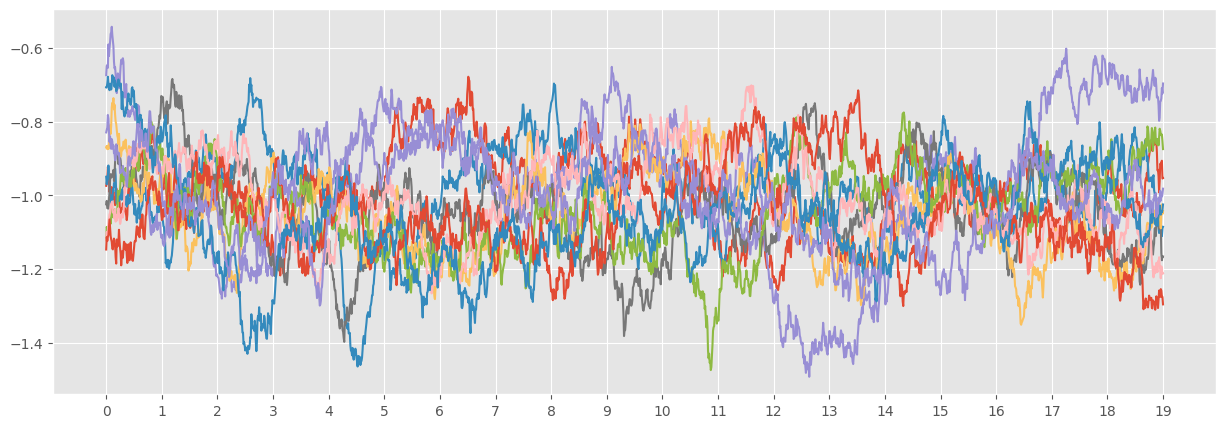

In [18]:
backward_samples = cd_r_pf.hist.backward_sampling_ON2(10)  # this will work
backward_samples_arr = np.concatenate([tools.struct_arr_to_arr(backward_samples[i]) for i in range(len(backward_samples))], axis=1).T

plt.figure(figsize=(15, 5))
plt.plot(times, backward_samples_arr)
plt.xticks(obs_times)
plt.show()

## (Bayesian) Parameter estimation

In the case of (standard) state space models, we can consider how to estimate the parameter $\theta=(\alpha, \rho, \sigma)$ from a given data-set. We present below how to run a parameter inference algorithm from the *particles* package: first, we set up a prior as follows.

In [19]:
prior_dict = {'mu':dists.Normal(), 
              'sigma': dists.Gamma(a=1., b=1.), 
              'rho':dists.Beta(9., 1.)}
my_prior = dists.StructDist(prior_dict)

The code above should be fairly readable: the prior for $\mu$ is $N(0,1)$, the one for $\sigma$ is a Gamma(1,1) and so on. 
(As before, probability distributions are represented by objects defined in the `distributions` module.)

This may not be a sensible prior distribution; for instance  it restricts $\rho$ to $[0,1]$. However, this will suffice for our purposes. 
A popular way to simulate from the posterior distribution of the parameters of a state-space model is PMMH, a particular instance of the PMCMC framework. Basically, this is a MCMC algorithm that runs at each iteration a particle filter so as to evaluate the likelihood. 


In [20]:
from particles import mcmc  # where the MCMC algorithms (PMMH, Particle Gibbs, etc) live
pmmh = mcmc.PMMH(ssm_cls=StochVol, prior=my_prior, data=data, Nx=50, niter = 1000)
pmmh.run()  # Warning: takes a few seconds

Again, the code above is hopefully readable: PMMH is run for 1000 iterations (`niter`), the particle filter run at each iteration have $N_x=50$ particles, and so on. One point worth mentioning is that we pass as an argument the *class* `StochVol`. Again, remember that this class indeed represents the considered parametric class (as opposed to `my_model`, which was a stochastic volatility model, for certain fixed parameter values). 

OK, we have waited long enough, let's plot the results.

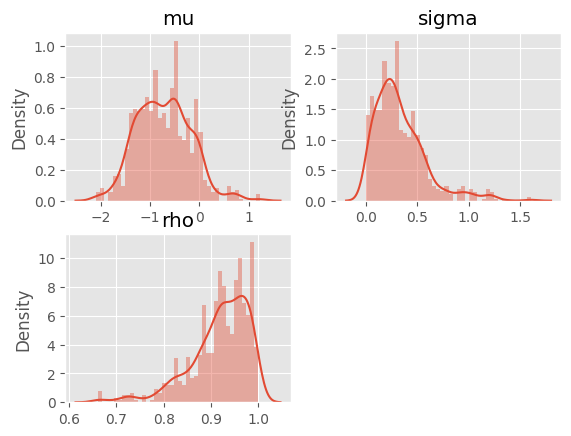

In [21]:
# plot the marginals 
burnin = 100  # discard the 100 first iterations
for i, param in enumerate(prior_dict.keys()):
    plt.subplot(2, 2, i+1)
    sb.distplot(pmmh.chain.theta[param][burnin:], 40)
    plt.title(param)

*The functionality to run PMCMC algorithms for parameter inference for CD-SSMs is still under development.* This notebook will be extended with examples of this feature in the next release.

## The end

The `particles-cdssm` package is still under active development - if you have any feedback, comments or complaints, please don't hesitate to reach out either through submitting a Github issue, or via e-mail: christopher.stanton.20@ucl.ac.uk.